# **Why does our platform need a sentiment model?**
---

1.  **Content Risk Control:** Automatically **identify negative** complaints, abusive remarks and inappropriate posts published by users on the platform, assist platform administrators to quickly carry out content review and risk disposal, maintain a healthy campus trading atmosphere.

2.  **Seller Reputation Quantification:** Calculate the **overall emotional** score of all commodity reviews under each seller, convert scattered comment texts into intuitive reputation data.

3.  **User Experience Improvement:** Collect aggregated user emotional feedback regarding platform trading rules, commodity categories and service experience, provide data basis for the iterative optimization of KKU'3S platform functions.

# **Model Shipping Criteria**
---
### Criterion 1: Overall Sentiment Performance
- **Objective:** Achieve balanced and high sentiment classification performance.
- **Primary Metric:** Macro F1-score
- **Supporting Metrics:** Accuracy, per-class Precision, Recall, and F1-score.

### Criterion 2: Negative Sentiment Detection
- **Objective:** Reliably identify negative feedback for timely intervention.
- **Primary Metric:** Negative Recall
- **Supporting Metrics:** Negative Precision and Negative F1-score.

### Criterion 3: Robustness Across Text Characteristics
- **Objective:** Maintain consistent performance across different types of user-generated text.
- **Primary Metrics:** Macro F1 and Negative Recall for each data slice.
- **Robustness Indicator:** Performance gap between different slices.
- **Initial Slices:**
  - Short vs. Long text
  - Emoji vs. No Emoji
  - Informal vs. Formal language
- **Note:** Final metadata attributes will be confirmed after further data analysis.

### Criterion 4: Prediction Reliability and Escalation
- **Objective:** Ensure that model confidence is sufficiently reliable for automated decisions.
- **Primary Metric:** Expected Calibration Error (ECE)
- **Supporting Analysis:** Confidence distribution and accuracy at different confidence thresholds.
- **Action Rule:** Predictions below the selected confidence threshold will be flagged for human review.

# **Exploratory Data Analysis**
---
The TweetEval sentiment test set is used as the common evaluation dataset for all models in this project.

Since the objective is to compare the baseline, the current production model, and candidate models under the same evaluation conditions, we perform exploratory data analysis on the test set before model inference.

The EDA focuses on the dataset structure, sentiment distribution, data quality, and textual characteristics that may influence model performance.

In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = "retina"
pd.options.display.max_colwidth = None
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

In [3]:
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

label_names = dataset["test"].features["label"].names
test_df["sentiment"] = test_df["label"].map(lambda x: label_names[x])


print(f"Test set size has {len(test_df):,} samples")
test_df.head(10)

Test set size has 12,284 samples


,text,label,sentiment
0,@user @user what do these '1/2 naked pics' have to do with anything? They're not even like that.,1,neutral
1,OH: “I had a blue penis while I was this” [playing with Google Earth VR],1,neutral
2,"@user @user That's coming, but I think the victims are going to be Medicaid recipients.",1,neutral
3,I think I may be finally in with the in crowd #mannequinchallenge #grads2014 @user,2,positive
4,"@user Wow,first Hugo Chavez and now Fidel Castro. Danny Glover, Michael Moore, Oliver Stone, and Sean Penn are running out of heroes.",0,negative
5,Savchenko now Saakashvili took drug test live on Ukraine TV. To prove they are not drug-fueled loonies?,1,neutral
6,How many more days until opening day? 😩,1,neutral
7,Twitter's #ThankYouObama Shows Heartfelt Gratitude To POTUS,2,positive
8,All CSG and Fracking all around Australia is to cease and Mining Entities held Accountable! - Sign the Petition!,1,neutral
9,@user @user @user @user @user @user take away illegals and dead people and Trump wins popular vote too.,0,negative


In [4]:
# Class Distribution
class_distribution = test_df["sentiment"].value_counts().reindex(label_names).reset_index()
class_distribution.columns = ["Sentiment", "Count"]
class_distribution["Percentage"] = round(class_distribution["Count"] / len(test_df) * 100,2)
class_distribution

,Sentiment,Count,Percentage
0,negative,3972,32.33
1,neutral,5937,48.33
2,positive,2375,19.33


In [5]:
test_df.isnull().sum()

text         0
label        0
sentiment    0
dtype: int64

In [6]:
empty_text = (
    test_df["text"]
    .fillna("")
    .str.strip()
    .eq("")
)

print(f"Empty texts: {empty_text.sum()}")

Empty texts: 0


In [7]:
print(
    f"Duplicate tweets: "
    f"{test_df['text'].duplicated().sum()}"
)

Duplicate tweets: 0


In [8]:
test_df["char_length"] = test_df["text"].str.len()
test_df["word_count"] = test_df["text"].str.split().str.len()
test_df[["char_length", "word_count"]].describe()

,char_length,word_count
count,12284.000000,12284.000000
mean,91.348095,14.859492
std,29.973303,5.565252
min,6.000000,1.000000
25%,69.000000,11.000000
50%,95.000000,15.000000
75%,115.000000,19.000000
max,141.000000,32.000000


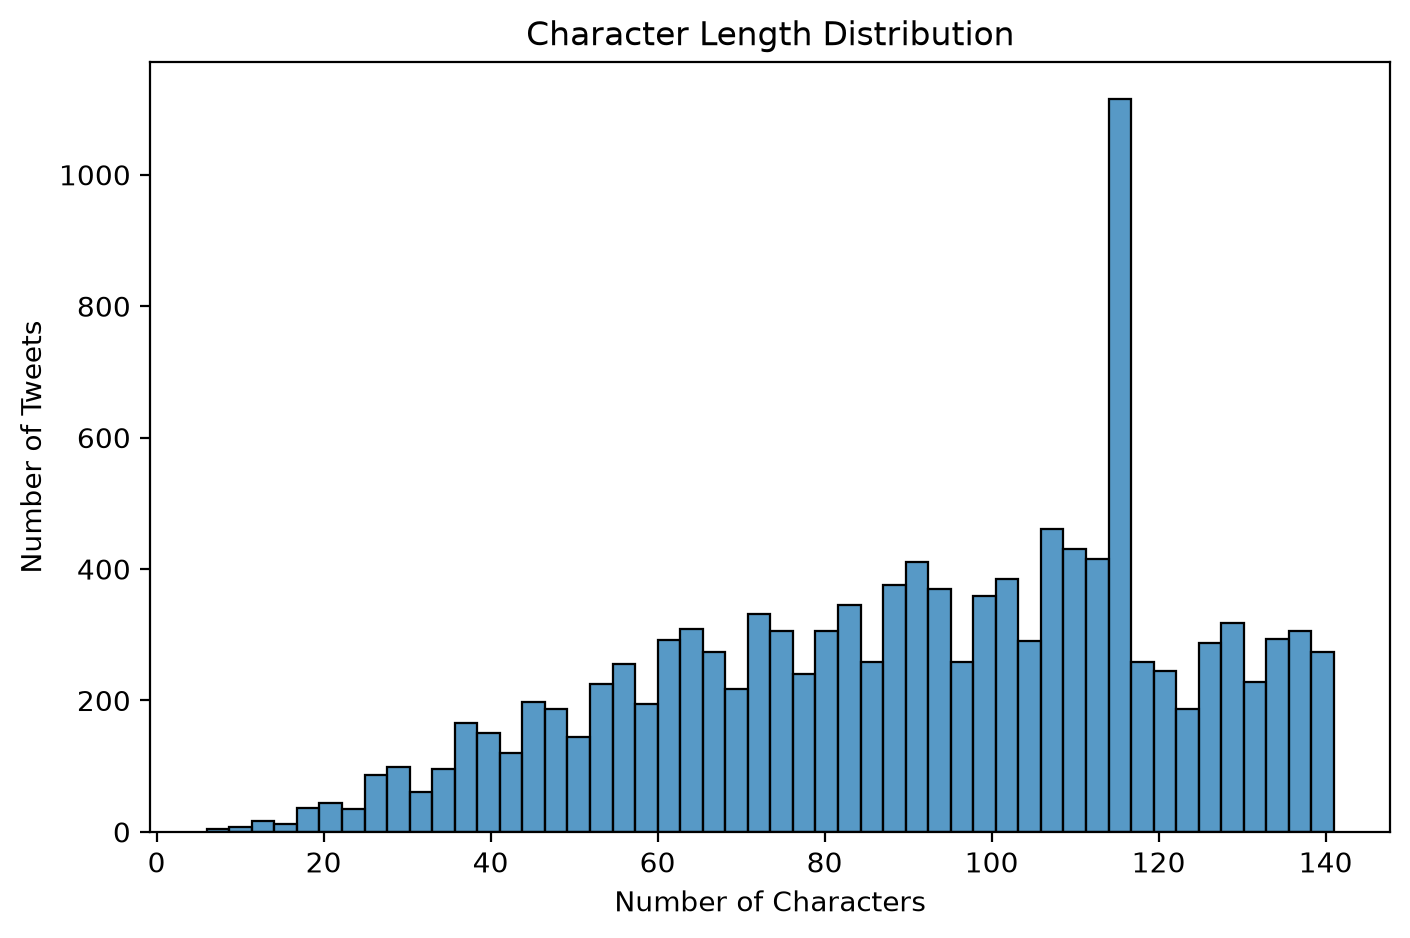

In [9]:
import seaborn as sns
plt.figure(figsize=(8, 5))

sns.histplot(data=test_df, x="char_length", bins=50)
plt.title("Character Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Tweets")

plt.show()

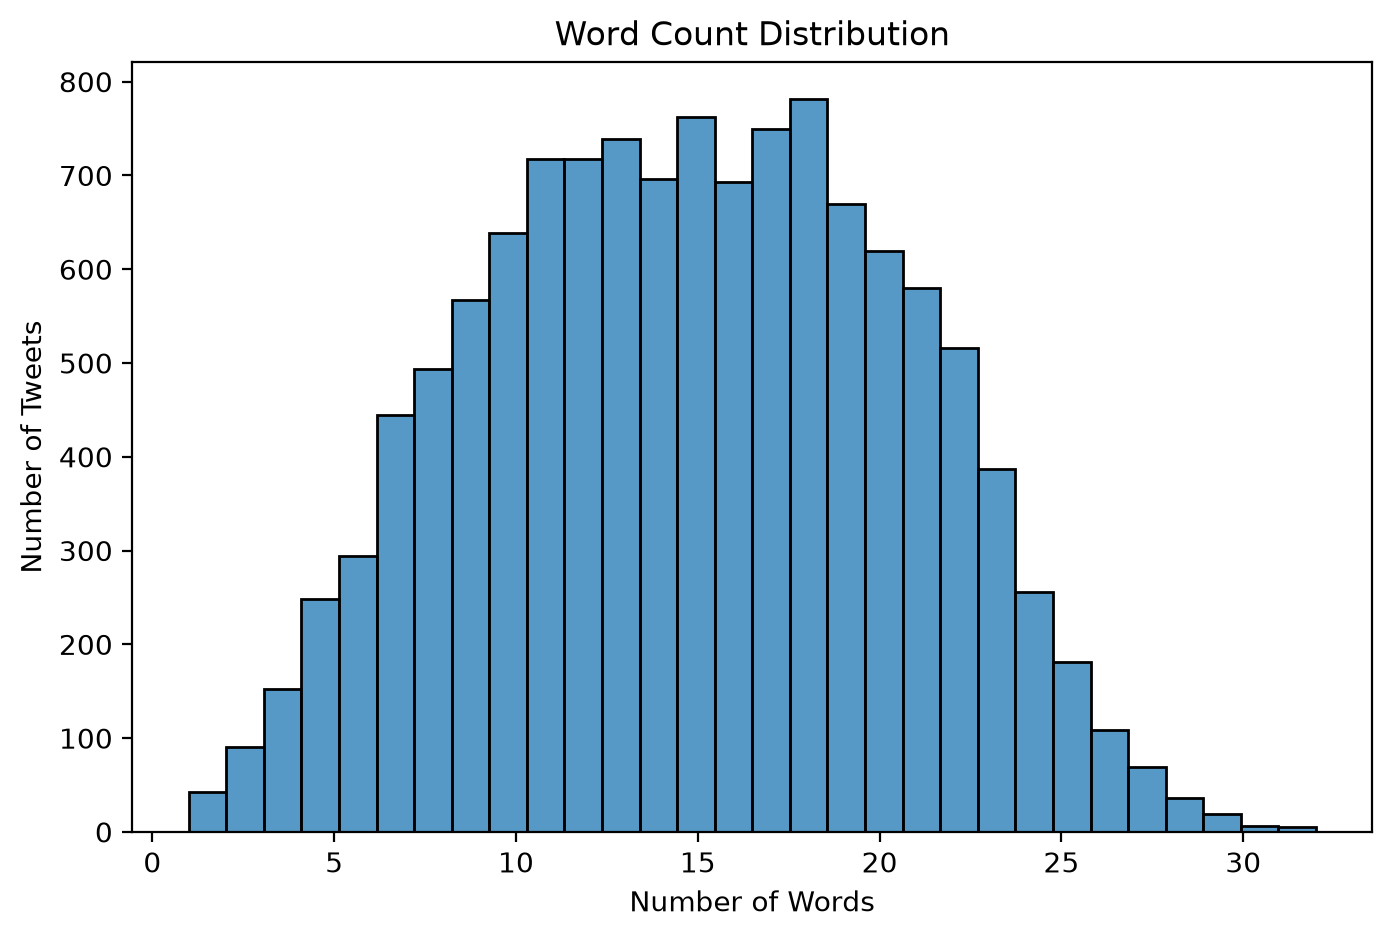

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(data=test_df, x="word_count", bins=30)
plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Tweets")
plt.show()

In [11]:
test_df.groupby("sentiment")[["char_length", "word_count"]].describe()

char_length                                                         \
                count        mean        std  min   25%    50%    75%    max   
sentiment                                                                      
negative       3972.0  101.384693  27.633562  9.0  84.0  109.0  122.0  140.0   
neutral        5937.0   87.544383  29.661132  7.0  65.0   90.0  112.0  141.0   
positive       2375.0   84.071158  30.223521  6.0  62.0   85.0  108.0  141.0   

          word_count                                                    
               count       mean       std  min   25%   50%   75%   max  
sentiment                                                               
negative      3972.0  16.801360  5.240580  1.0  13.0  17.0  21.0  32.0  
neutral       5937.0  13.990568  5.405203  1.0  10.0  14.0  18.0  31.0  
positive      2375.0  13.784000  5.648217  1.0  10.0  13.0  18.0  32.0

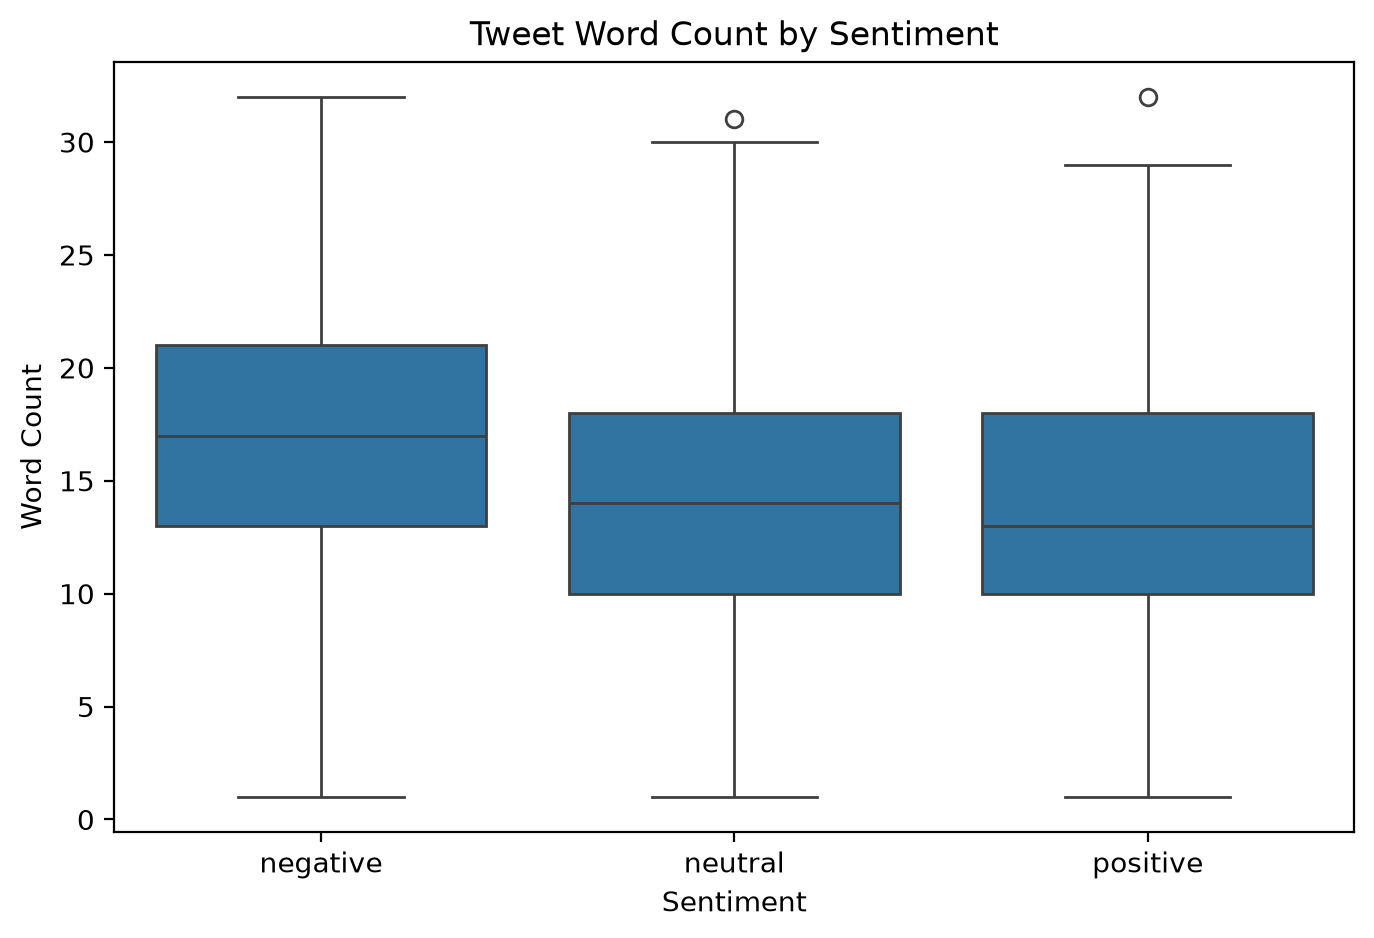

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=test_df, x="sentiment", y="word_count", order=label_names)
plt.title("Tweet Word Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Word Count")

plt.show()

In [13]:
import re

test_df["has_url"] = test_df["text"].str.contains(r"https?://\S+|www\.\S+", regex=True, na=False)
test_df["has_hashtag"] = test_df["text"].str.contains(r"#\w+", regex=True, na=False)
test_df["has_mention"] = test_df["text"].str.contains(r"@\w+", regex=True, na=False)

def has_emoji(text):
    if not isinstance(text, str):
        return False
    for char in text:
        code = ord(char)
        if (
            0x1F300 <= code <= 0x1FAFF
            or 0x2600 <= code <= 0x27BF
        ):
            return True

    return False

test_df["has_emoji"] = test_df["text"].apply(has_emoji)
characteristic_summary = pd.DataFrame({
    "Characteristic": ["URL", "Hashtag", "Mention", "Emoji"],
    "Count": [
        test_df["has_url"].sum(),
        test_df["has_hashtag"].sum(),
        test_df["has_mention"].sum(),
        test_df["has_emoji"].sum()
    ]
})

characteristic_summary["Percentage"] = round(characteristic_summary["Count"] / len(test_df) * 100, 2)
characteristic_summary

,Characteristic,Count,Percentage
0,URL,376,3.06
1,Hashtag,4823,39.26
2,Mention,4997,40.68
3,Emoji,802,6.53


# EDA Summary

The TweetEval test set contains 12,284 tweets across three sentiment classes: positive, neutral, and negative.

The class distribution is 32.3%, 48.3%, 19.3% for negative, neutral and positive respectively.

Regarding data quality, we did't found NULL, Duplicate values.

These observations provide an initial understanding of the evaluation dataset and will be used to guide subsequent data preparation and model behavior analysis.

# **Models**
---

# Candidate Model Selection

We selected two additional sentiment models from Hugging Face as candidate models.

The candidate models were selected based on their relevance to the target application, their suitability for sentiment classification, and their differences from the existing baseline model.

The selection does not involve additional model training. All selected models are pretrained models that can directly perform sentiment inference.

### Candidate 1: Twitter-XLM-RoBERTa

The first candidate model is `cardiffnlp/twitter-xlm-roberta-base-sentiment`.

This model was selected because it is specifically designed for sentiment analysis of Twitter data while using a multilingual XLM-RoBERTa architecture.

Compared with the English Twitter-RoBERTa baseline, this model provides a different pretrained representation and multilingual capability.

This allows us to investigate whether a multilingual Twitter sentiment model can provide more robust sentiment classification than the baseline.

### Candidate 2: RoBERTa Sentiment Model

The second candidate model is `cardiffnlp/roberta-base-sentiment`.

This model was selected because it uses the general RoBERTa architecture rather than Twitter-specific pretraining.

Comparing this model with the Twitter-RoBERTa baseline allows us to investigate whether Twitter-specific pretraining provides an advantage for sentiment classification.

In [ ]:
from transformers import pipeline

baseline_model = "cardiffnlp/twitter-roberta-base-sentiment-latest"
baseline_classifier = pipeline("sentiment-analysis", model=baseline_model)

production_model = "LYTinn/gpt2-finetuning-sentiment-model-3000-samples"
production_classifier = pipeline("sentiment-analysis", model=production_model)

candidate1_model = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
candidate1_classifier = pipeline("sentiment-analysis", model=candidate1_model)

candidate2_model = "cardiffnlp/roberta-base-sentiment"
candidate2_classifier = pipeline("sentiment-analysis", model=candidate2_model)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: LYTinn/gpt2-finetuning-sentiment-model-3000-samples
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

model.safetensors: downloading bytes:           |  0.00B            

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

# Check Model Output Label

The current production model is a binary sentiment classifier trained on IMDb, whereas the TweetEval evaluation task contains three sentiment classes: negative, neutral, and positive.

In [17]:
# Check model output label
print("BASELINE")
print(baseline_classifier.model.config.id2label)

print("\nPRODUCTION")
print(production_classifier.model.config.id2label)

print("\nCANDIDATE 1")
print(candidate1_classifier.model.config.id2label)

print("\nCANDIDATE 2")
print(candidate2_classifier.model.config.id2label)

models = {
    "baseline": baseline_classifier,
    "production": production_classifier,
    "candidate_1": candidate1_classifier,
    "candidate_2": candidate2_classifier
}

BASELINE
{0: 'negative', 1: 'neutral', 2: 'positive'}

PRODUCTION
{0: 'LABEL_0', 1: 'LABEL_1'}

CANDIDATE 1
{0: 'negative', 1: 'neutral', 2: 'positive'}

CANDIDATE 2
{0: 'negative', 1: 'neutral', 2: 'positive'}


| Role        | Model                                                 | Classes                       |
| ----------- | ----------------------------------------------------- | ----------------------------- |
| Baseline    | `cardiffnlp/twitter-roberta-base-sentiment-latest`    | Negative / Neutral / Positive |
| Production  | `LYTinn/gpt2-finetuning-sentiment-model-3000-samples` | Negative / Positive           |
| Candidate 1 | `cardiffnlp/twitter-xlm-roberta-base-sentiment`       | Negative / Neutral / Positive |
| Candidate 2 | `cardiffnlp/roberta-base-sentiment`                   | Negative / Neutral / Positive |


## Quick Test

In [21]:
from tqdm.auto import tqdm
texts = test_df["text"].tolist()
results = {}
for model_name, classifier in models.items():
    print(f"Running {model_name}...")
    outputs = []
    for text in tqdm(texts):
        result = classifier(text)[0]
        outputs.append({
            "label": result["label"],
            "confidence": result["score"]
        })
    results[model_name] = outputs

Running baseline...


  0%|          | 0/12284 [00:00<?, ?it/s]

Running production...


  0%|          | 0/12284 [00:00<?, ?it/s]

Running candidate_1...


  0%|          | 0/12284 [00:00<?, ?it/s]

Running candidate_2...


  0%|          | 0/12284 [00:00<?, ?it/s]

In [27]:
# Put the results into test DataFrame

for model_name, outputs in results.items():
    test_df[f"{model_name}_prediction"] = [
        x["label"] for x in outputs
    ]
    
    test_df[f"{model_name}_confidence"] = [
        x["confidence"] for x in outputs
    ]

production_mapping = {
    "LABEL_0": "negative",
    "LABEL_1": "positive"
}

test_df["production_prediction"] = (
    test_df["production_prediction"]
    .map(production_mapping)
)
test_df.head()

,text,label,sentiment,char_length,word_count,has_url,has_hashtag,has_mention,has_emoji,baseline_prediction,baseline_confidence,production_prediction,production_confidence,candidate_1_prediction,candidate_1_confidence,candidate_2_prediction,candidate_2_confidence
0,@user @user what do these '1/2 naked pics' have to do with anything? They're not even like that.,1,neutral,96,18,False,False,True,False,negative,0.804726,negative,1.000000,negative,0.578722,negative,0.867132
1,OH: “I had a blue penis while I was this” [playing with Google Earth VR],1,neutral,72,15,False,False,False,False,neutral,0.866949,negative,0.985484,neutral,0.825280,neutral,0.776679
2,"@user @user That's coming, but I think the victims are going to be Medicaid recipients.",1,neutral,87,15,False,False,True,False,neutral,0.763725,negative,0.695120,neutral,0.614876,negative,0.799746
3,I think I may be finally in with the in crowd #mannequinchallenge #grads2014 @user,2,positive,83,14,False,True,True,False,positive,0.774047,positive,0.782224,positive,0.537997,positive,0.885333
4,"@user Wow,first Hugo Chavez and now Fidel Castro. Danny Glover, Michael Moore, Oliver Stone, and Sean Penn are running out of heroes.",0,negative,133,22,False,False,True,False,neutral,0.416397,positive,0.999927,negative,0.786067,neutral,0.525170


Test without production model

In [30]:
from sklearn.metrics import classification_report

model_names = [
    "baseline",
    "production",
    "candidate_1",
    "candidate_2"
]

for model_name in model_names:
    print("=" * 70)
    print(model_name.upper())
    print("=" * 70)

    y_true = test_df["sentiment"]
    y_pred = test_df[f"{model_name}_prediction"]

    print(
        classification_report(
            y_true,
            y_pred,
            labels=["negative", "neutral", "positive"],
            zero_division=0
        )
    )

BASELINE
              precision    recall  f1-score   support

    negative       0.69      0.81      0.74      3972
     neutral       0.76      0.66      0.70      5937
    positive       0.71      0.74      0.73      2375

    accuracy                           0.72     12284
   macro avg       0.72      0.73      0.72     12284
weighted avg       0.73      0.72      0.72     12284

PRODUCTION
              precision    recall  f1-score   support

    negative       0.32      0.54      0.41      3972
     neutral       0.00      0.00      0.00      5937
    positive       0.22      0.52      0.31      2375

    accuracy                           0.28     12284
   macro avg       0.18      0.36      0.24     12284
weighted avg       0.15      0.28      0.19     12284

CANDIDATE_1
              precision    recall  f1-score   support

    negative       0.61      0.87      0.72      3972
     neutral       0.77      0.55      0.64      5937
    positive       0.68      0.70      0.69

**Baseline**

| Class            | Precision |   Recall | F1-Score |    Support |
| ---------------- | --------: | -------: | -------: | ---------: |
| Negative         |      0.69 |     0.81 |     0.74 |      3,972 |
| Neutral          |      0.76 |     0.66 |     0.70 |      5,937 |
| Positive         |      0.71 |     0.74 |     0.73 |      2,375 |
| **Accuracy**     |           |          | **0.72** | **12,284** |
| **Macro Avg**    |  **0.72** | **0.73** | **0.72** | **12,284** |
| **Weighted Avg** |  **0.73** | **0.72** | **0.72** | **12,284** |

**Production Model**
| Class            | Precision |   Recall | F1-Score |    Support |
| ---------------- | --------: | -------: | -------: | ---------: |
| Negative         |      0.32 |     0.54 |     0.41 |      3,972 |
| Neutral          |      0.00 |     0.00 |     0.00 |      5,937 |
| Positive         |      0.22 |     0.52 |     0.31 |      2,375 |
| **Accuracy**     |           |          | **0.28** | **12,284** |
| **Macro Avg**    |  **0.18** | **0.36** | **0.24** | **12,284** |
| **Weighted Avg** |  **0.15** | **0.28** | **0.19** | **12,284** |

**Candidate 1 — Twitter-XLM-RoBERTa**
| Class            | Precision |   Recall | F1-Score |    Support |
| ---------------- | --------: | -------: | -------: | ---------: |
| Negative         |      0.61 | **0.87** |     0.72 |      3,972 |
| Neutral          |      0.77 |     0.55 |     0.64 |      5,937 |
| Positive         |      0.68 |     0.70 |     0.69 |      2,375 |
| **Accuracy**     |           |          | **0.68** | **12,284** |
| **Macro Avg**    |  **0.69** | **0.71** | **0.68** | **12,284** |
| **Weighted Avg** |  **0.70** | **0.68** | **0.68** | **12,284** |

**Candidate 2 — RoBERTa-base-sentiment**
| Class            | Precision |   Recall | F1-Score |    Support |
| ---------------- | --------: | -------: | -------: | ---------: |
| Negative         |      0.70 |     0.79 |     0.74 |      3,972 |
| Neutral          |      0.76 |     0.63 |     0.69 |      5,937 |
| Positive         |      0.64 |     0.77 |     0.70 |      2,375 |
| **Accuracy**     |           |          | **0.71** | **12,284** |
| **Macro Avg**    |  **0.70** | **0.73** | **0.71** | **12,284** |
| **Weighted Avg** |  **0.72** | **0.71** | **0.71** | **12,284** |
